In [1]:
from google.colab import drive
# 執行此程式碼以掛載 Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!ls

drive  sample_data


In [3]:
%cd /content/drive/MyDrive/data

/content/drive/MyDrive/data


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

In [12]:
# ==== 1. 設定路徑 ====
train_dir = "train"   # train/cat/, train/dog/
val_dir = "validation"       # val/cat/, val/dog/

In [13]:
# ==== 2. 影像增強 ====
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 60 images belonging to 2 classes.
Found 59 images belonging to 2 classes.


In [14]:
# ==== 3. 載入 VGG16 預訓練模型 ====
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 凍結卷積層，避免破壞預訓練權重
for layer in base_model.layers:
    layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
# ==== 4. 建立分類模型 ====
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [17]:
# ==== 5. 編譯模型 ====
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [18]:
# ==== 6. 訓練模型 ====
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 88s 70s/step - accuracy: 0.5476 - loss: 0.8514 - val_accuracy: 0.5424 - val_loss: 0.6779
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 65s 49s/step - accuracy: 0.4778 - loss: 0.8113 - val_accuracy: 0.4915 - val_loss: 0.7424
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 65s 47s/step - accuracy: 0.5660 - loss: 0.7559 - val_accuracy: 0.8305 - val_loss: 0.5414
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 66s 49s/step - accuracy: 0.7611 - loss: 0.5284 - val_accuracy: 0.7458 - val_loss: 0.5229
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 64s 48s/step - accuracy: 0.5794 - loss: 0.6547 - val_accuracy: 0.9153 - val_loss: 0.4737
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 66s 47s/step - accuracy: 0.7299 - loss: 0.5628 - val_accuracy: 0.6949 - val_loss: 0.5100
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 65s 49s/step - accuracy: 0.8071 - loss: 0.4926 - val_accuracy: 0.6949 - val_loss: 0.4989
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 65s 49s/step - accuracy: 0.6460 - loss: 0.6117 - val_accuracy: 0.9322 - val_loss: 0.4018


In [19]:
# ==== 7. 儲存模型 ====
model.save("cat_dog_vgg16.h5")

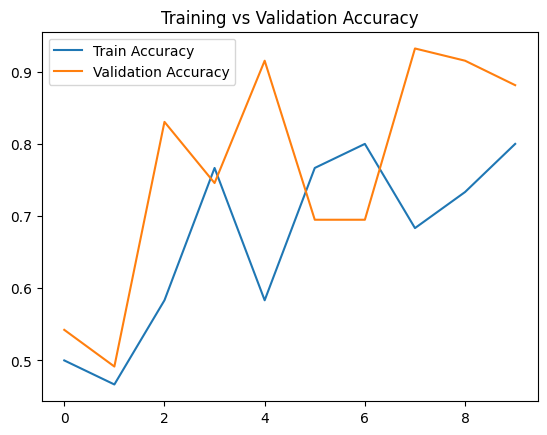

In [20]:
# ==== 8. 顯示訓練結果 ====
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()